In [1]:
%load_ext autoreload
%autoreload 2
%aimport -torch

In [2]:
import torch
try:  
    # Attempt to disable torch.compile for faster iteration, but if it fails 
    # (probably due to older pytorch version) we just proceed anyway
    torch.compiler.set_stance("force_eager")
except:
    pass

import sys
import os
from utils import load_all_images

TOKENIZER_PATH = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/FlowMo'
TOKENIZER = os.path.basename(TOKENIZER_PATH)

sys.path.append(TOKENIZER_PATH)

from omegaconf import OmegaConf
from flowmo import train_utils
import mediapy, einops
import numpy as np
import torchvision.transforms as T
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
# Set up the data.
config = OmegaConf.load('FlowMo/flowmo/configs/base.yaml')
config.data.batch_size = 4
config.data.num_workers = 0

In [4]:
def preprocess_image(image_path, size=256, device='cuda', disable_resize=False):
    """Load and preprocess a single image for FlowMo"""
    # Load image
    image = Image.open(image_path).convert("RGB")
    image.load()
    
    if disable_resize:
        # Only center crop without resizing - keeps original pixel resolution
        cropper = T.CenterCrop((size, size))
        image = cropper(image)
    else:
        # Preprocess (same as FlowMo)
        rescaler = T.Resize(size, interpolation=T.InterpolationMode.LANCZOS)  # High quality
        cropper = T.CenterCrop((size, size))
        preprocessor = T.Compose([rescaler, cropper])
        image = preprocessor(image)
    
    image = np.array(image)
    image = (image / 127.5 - 1.0).astype(np.float32)  # FlowMo normalization
    
    # Convert to tensor (C, H, W) for model
    tensor = torch.from_numpy(image).permute(2, 0, 1).to(device)
    return tensor


def tensor_to_pil(tensor):
    """Convert tensor back to PIL image"""
    # Tensor is in range [-1, 1], convert back to [0, 255]
    tensor = (tensor + 1.0) * 127.5
    tensor = tensor.clamp(0, 255)
    
    # Convert CHW to HWC and to numpy
    if tensor.dim() == 4:  # Remove batch dimension if present
        tensor = tensor.squeeze(0)
    image_array = tensor.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    
    return Image.fromarray(image_array)

In [5]:
# Choose your 

model_name = "flowmo_lo"  

# The low BPP model has 18 bits per token, the high bitrate model has 56 bits per token.
zoo = {
    "flowmo_lo": {"context_dim": 18, "ckpt_path": "FlowMo/flowmo_lo.pth"},
    "flowmo_hi": {"context_dim": 56, "ckpt_path": "FlowMo/flowmo_hi.pth"},
}

RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{model_name}'
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

state_dict = torch.load(zoo[model_name]['ckpt_path'], map_location='cuda:0')
config.model.context_dim = zoo[model_name]['context_dim']
config.model.codebook_size_for_entropy = 1  # don't need this at test time.
model = train_utils.build_model(config)
model.load_state_dict(state_dict['model_ema_state_dict'])
model = model.cuda()

print(f"Model config code_length: {model.code_length}")
print(f"Model config context_dim: {model.config.model.context_dim}")
print(f"Zoo config: {zoo[model_name]}")


/tmp/ipykernel_95791/2903706240.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(zoo[model_name]['ckpt_path'], map_location='cuda:0')


Mup enabled!
Model config code_length: 256
Model config context_dim: 18
Zoo config: {'context_dim': 18, 'ckpt_path': 'FlowMo/flowmo_lo.pth'}


In [7]:
# Simple loop for FlowMo processing
folder_path = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original'
_, _, image_paths = load_all_images(folder_path)

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png



Processing image 1: graph_theory1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: graph_theory1_256.png


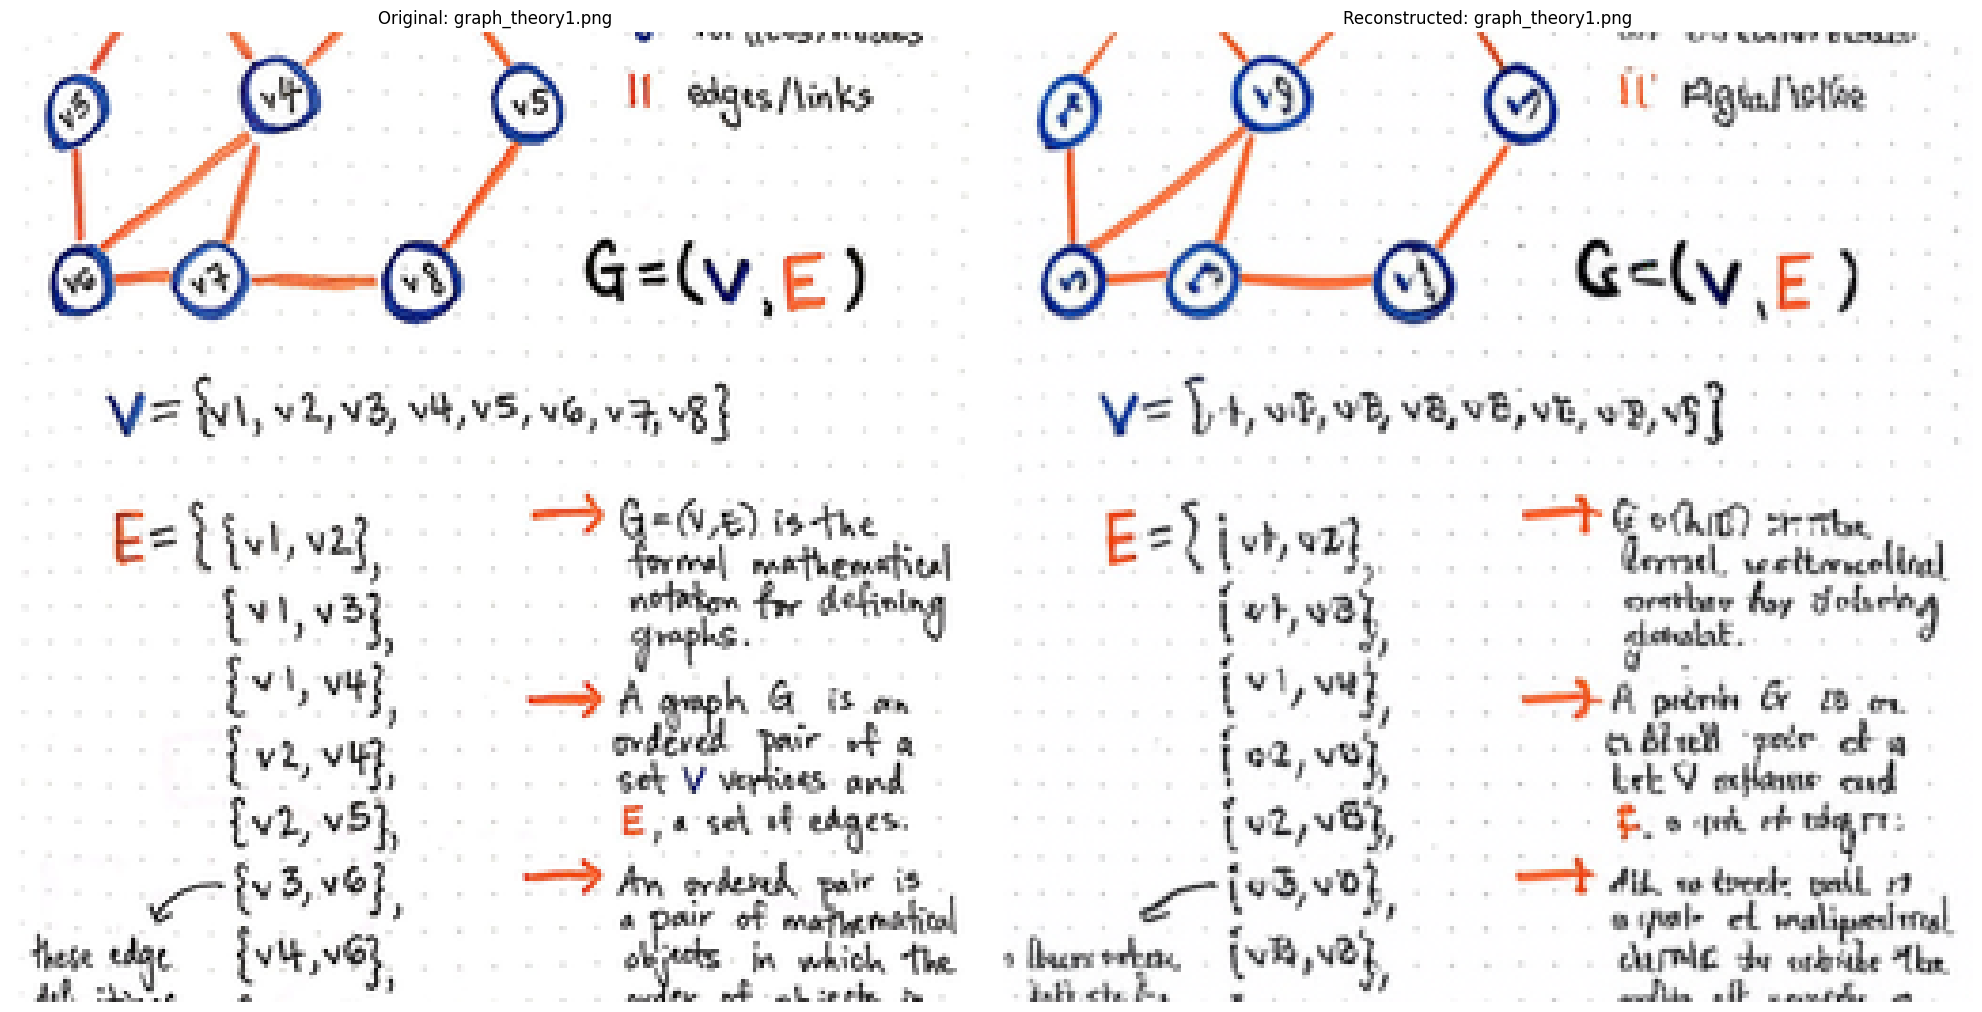


Processing image 2: line_chart.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: line_chart_256.png


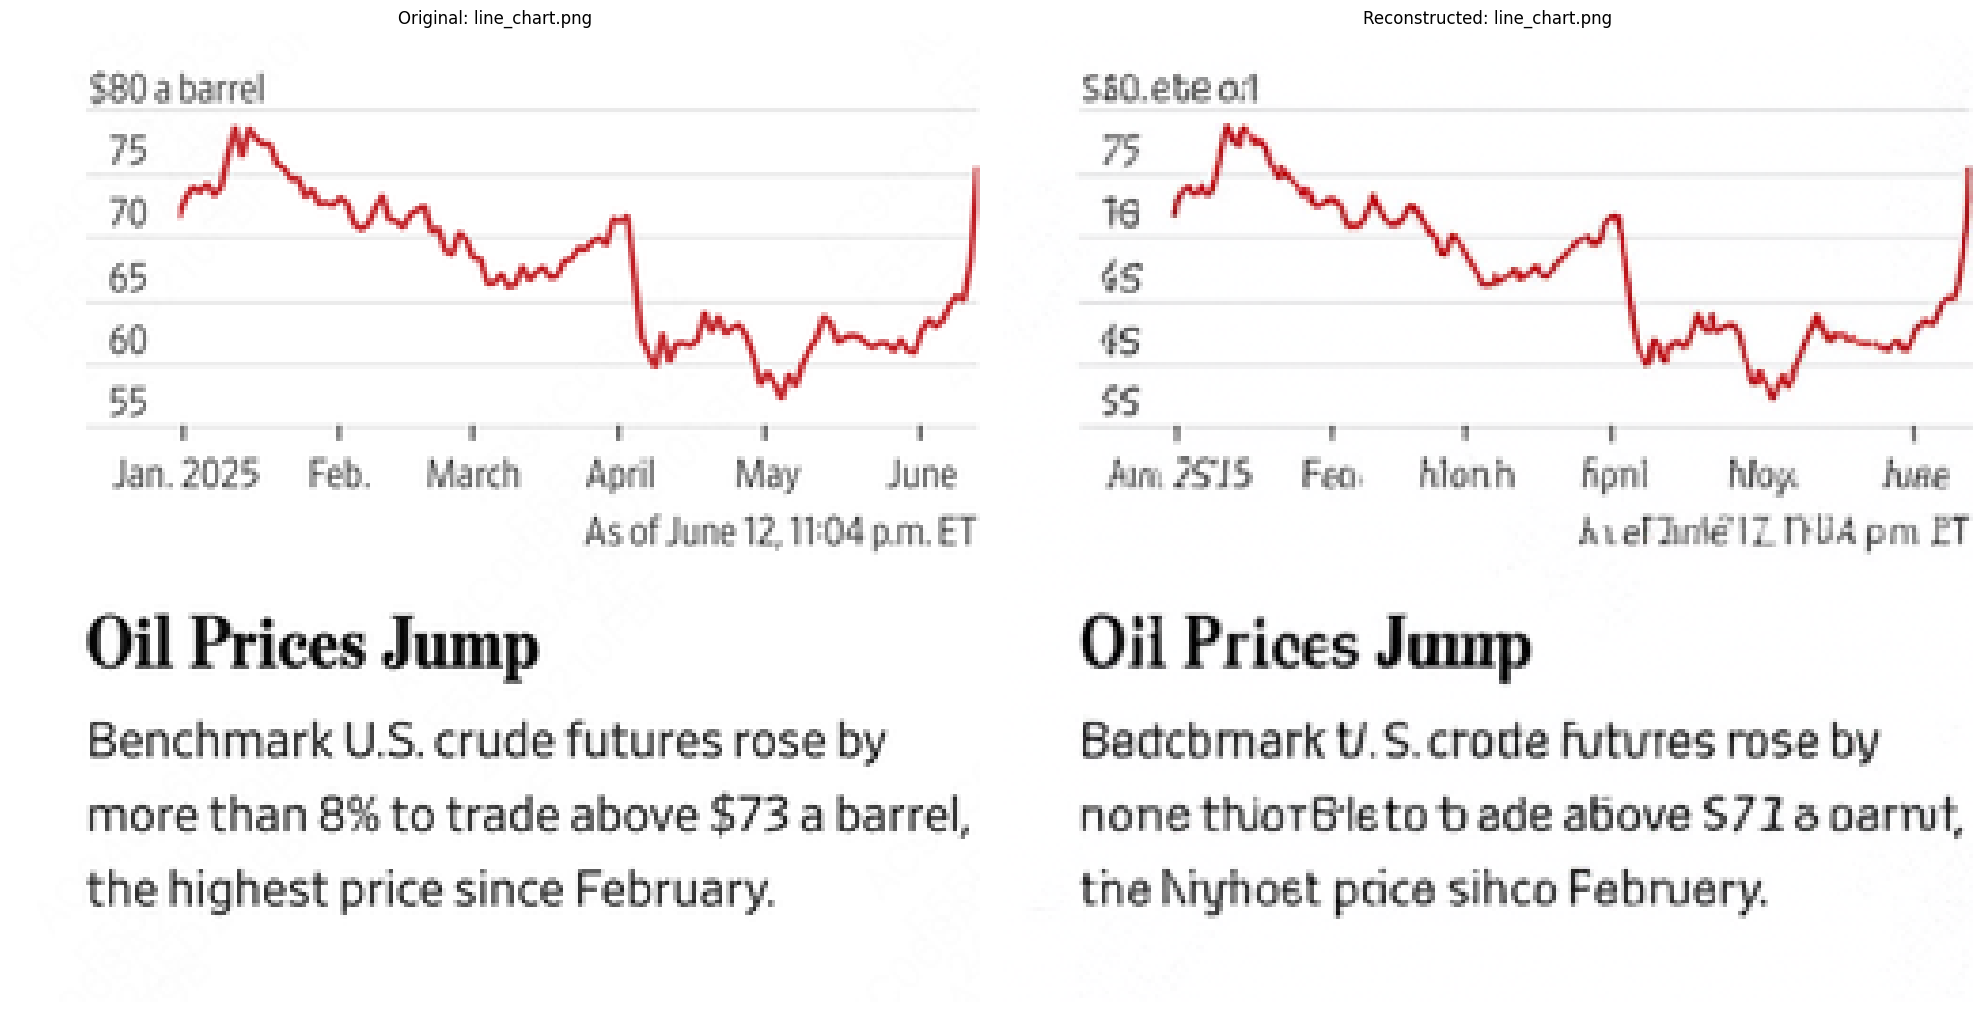


Processing image 3: logo1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: logo1_256.png


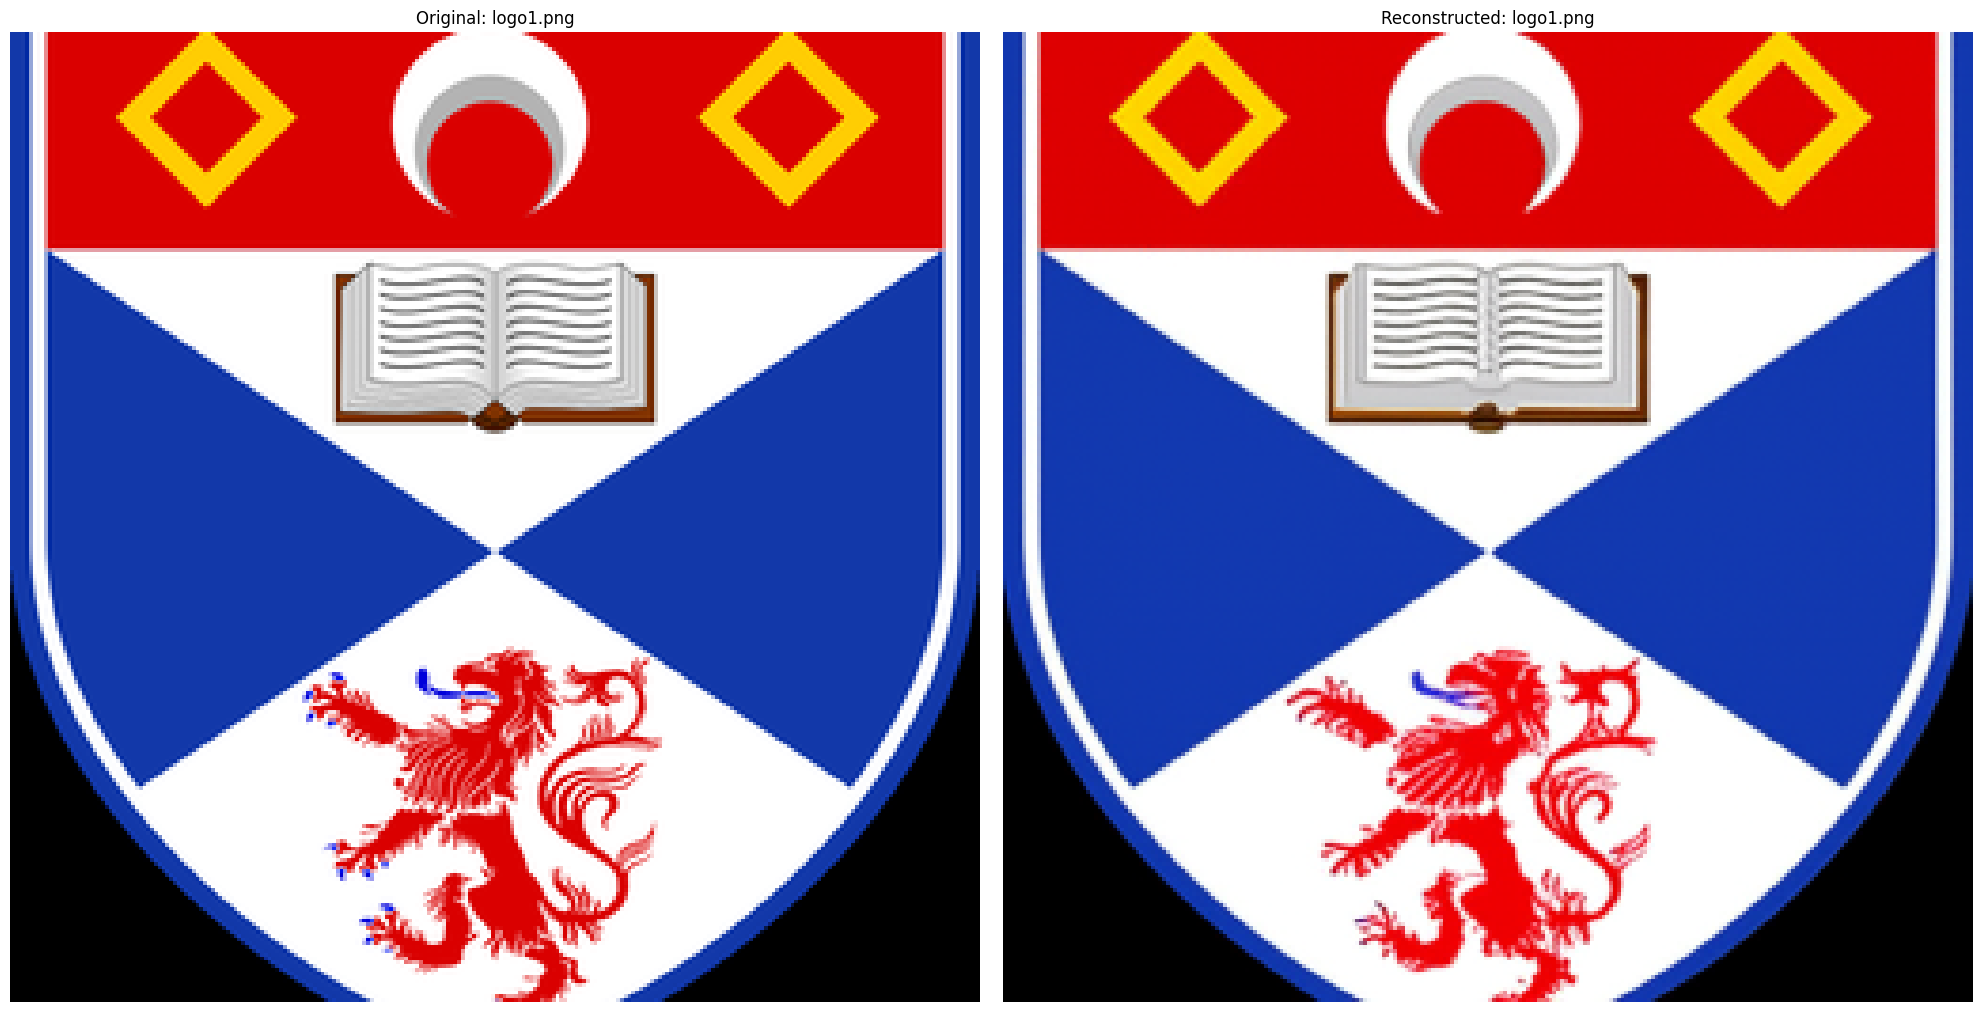


Processing image 4: logo2.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: logo2_256.png


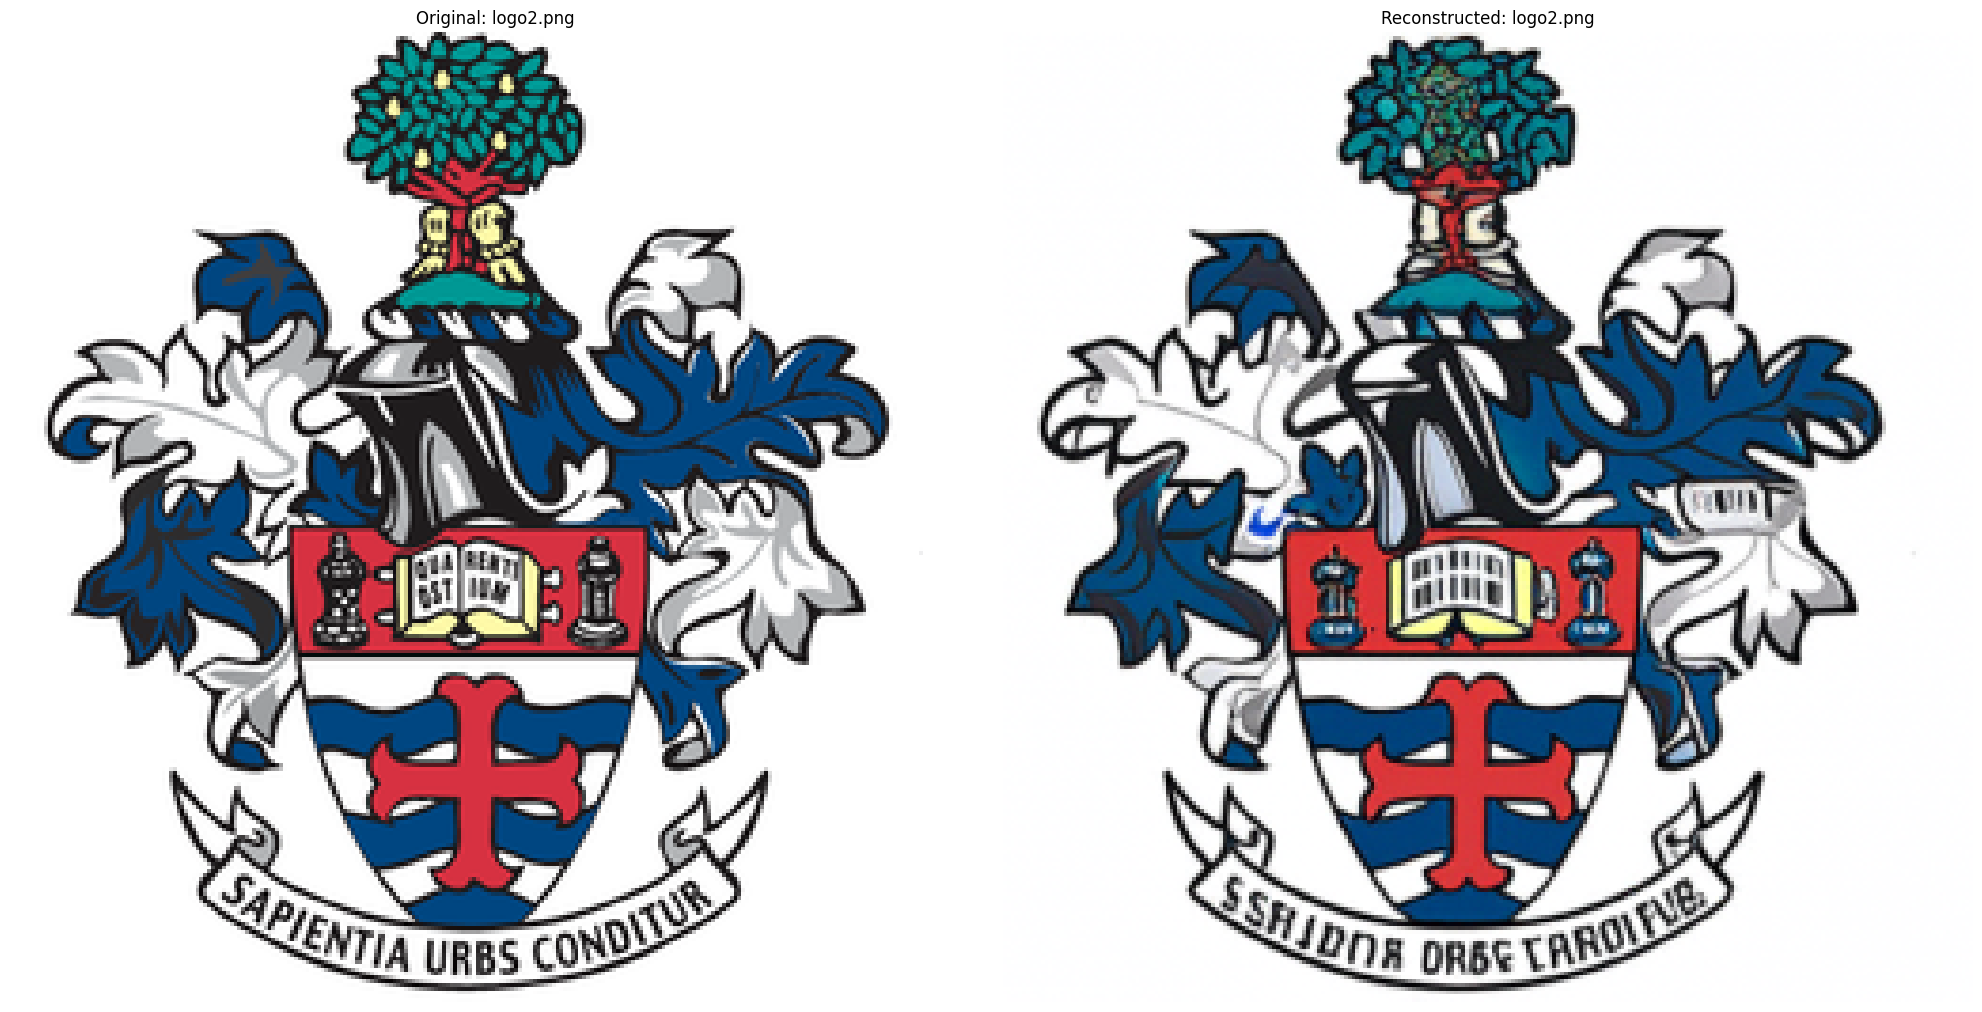


Processing image 5: math_draft1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: math_draft1_256.png


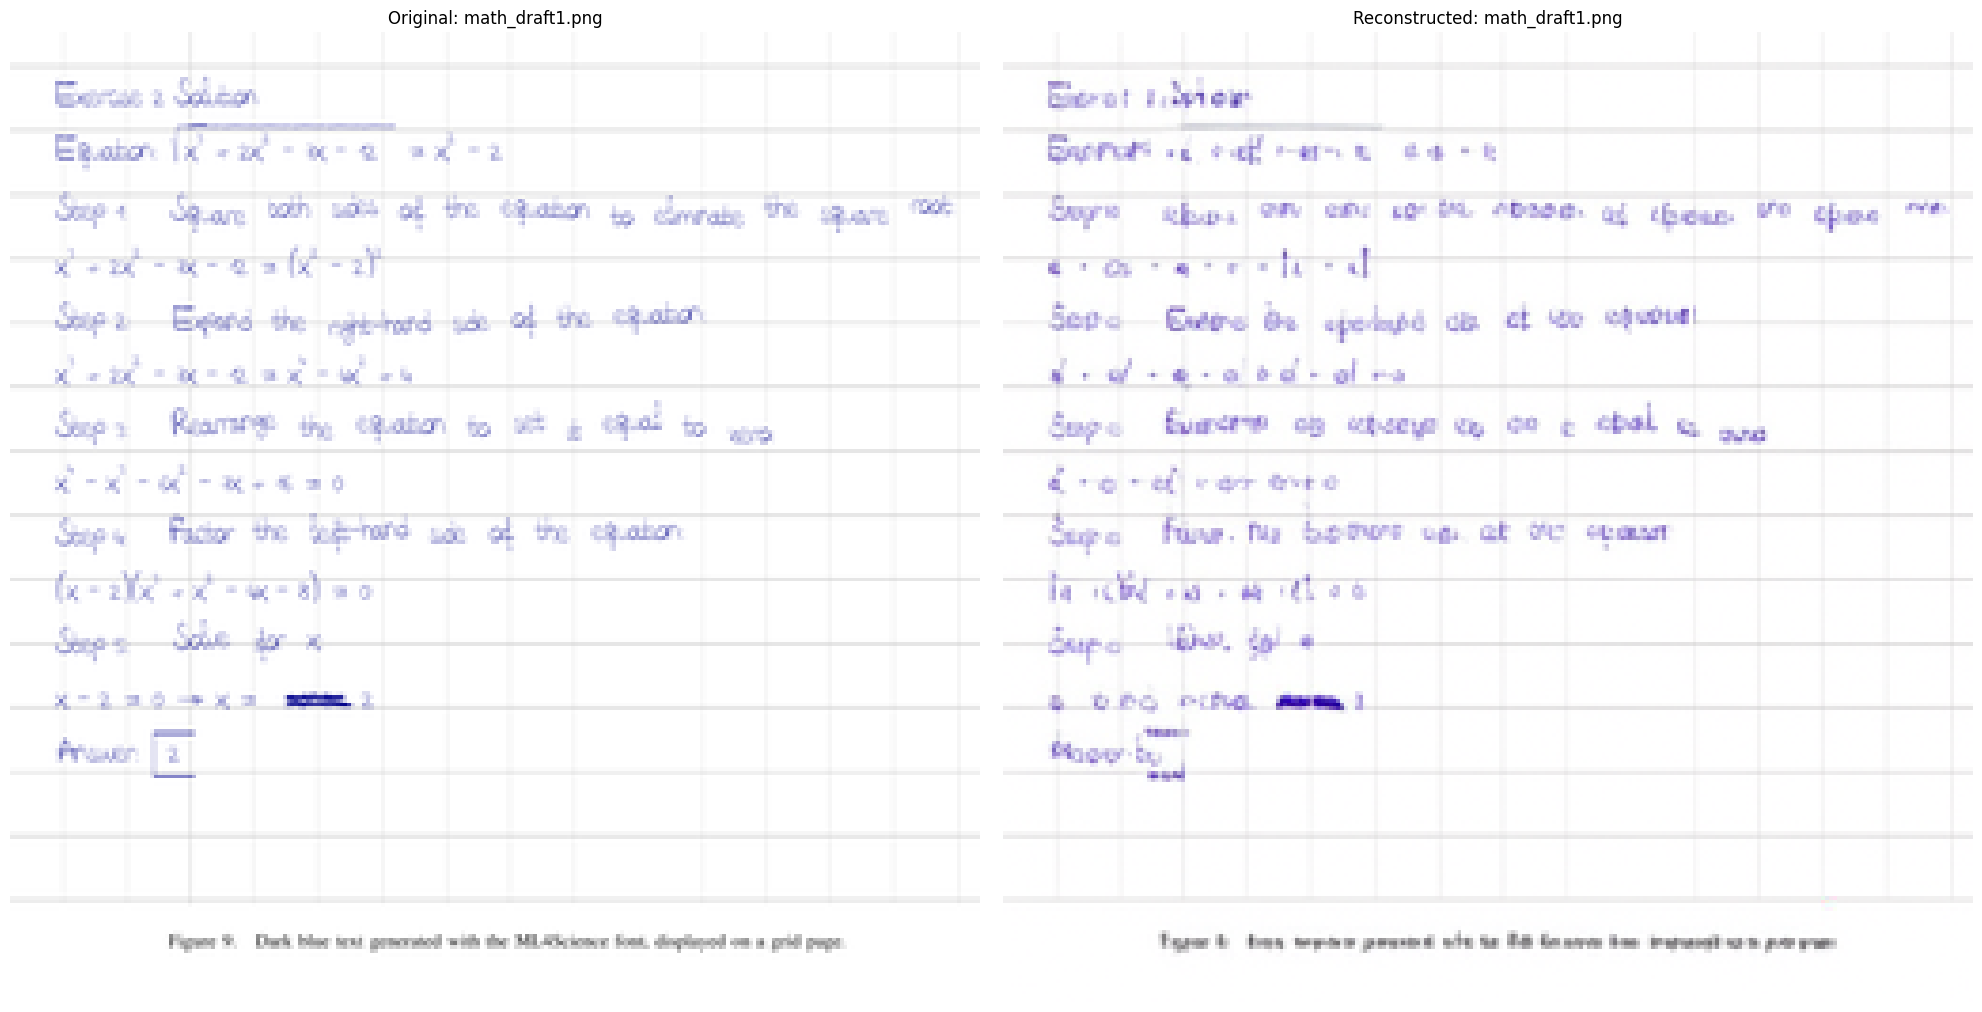


Processing image 6: menu.jpeg
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: menu_256.png


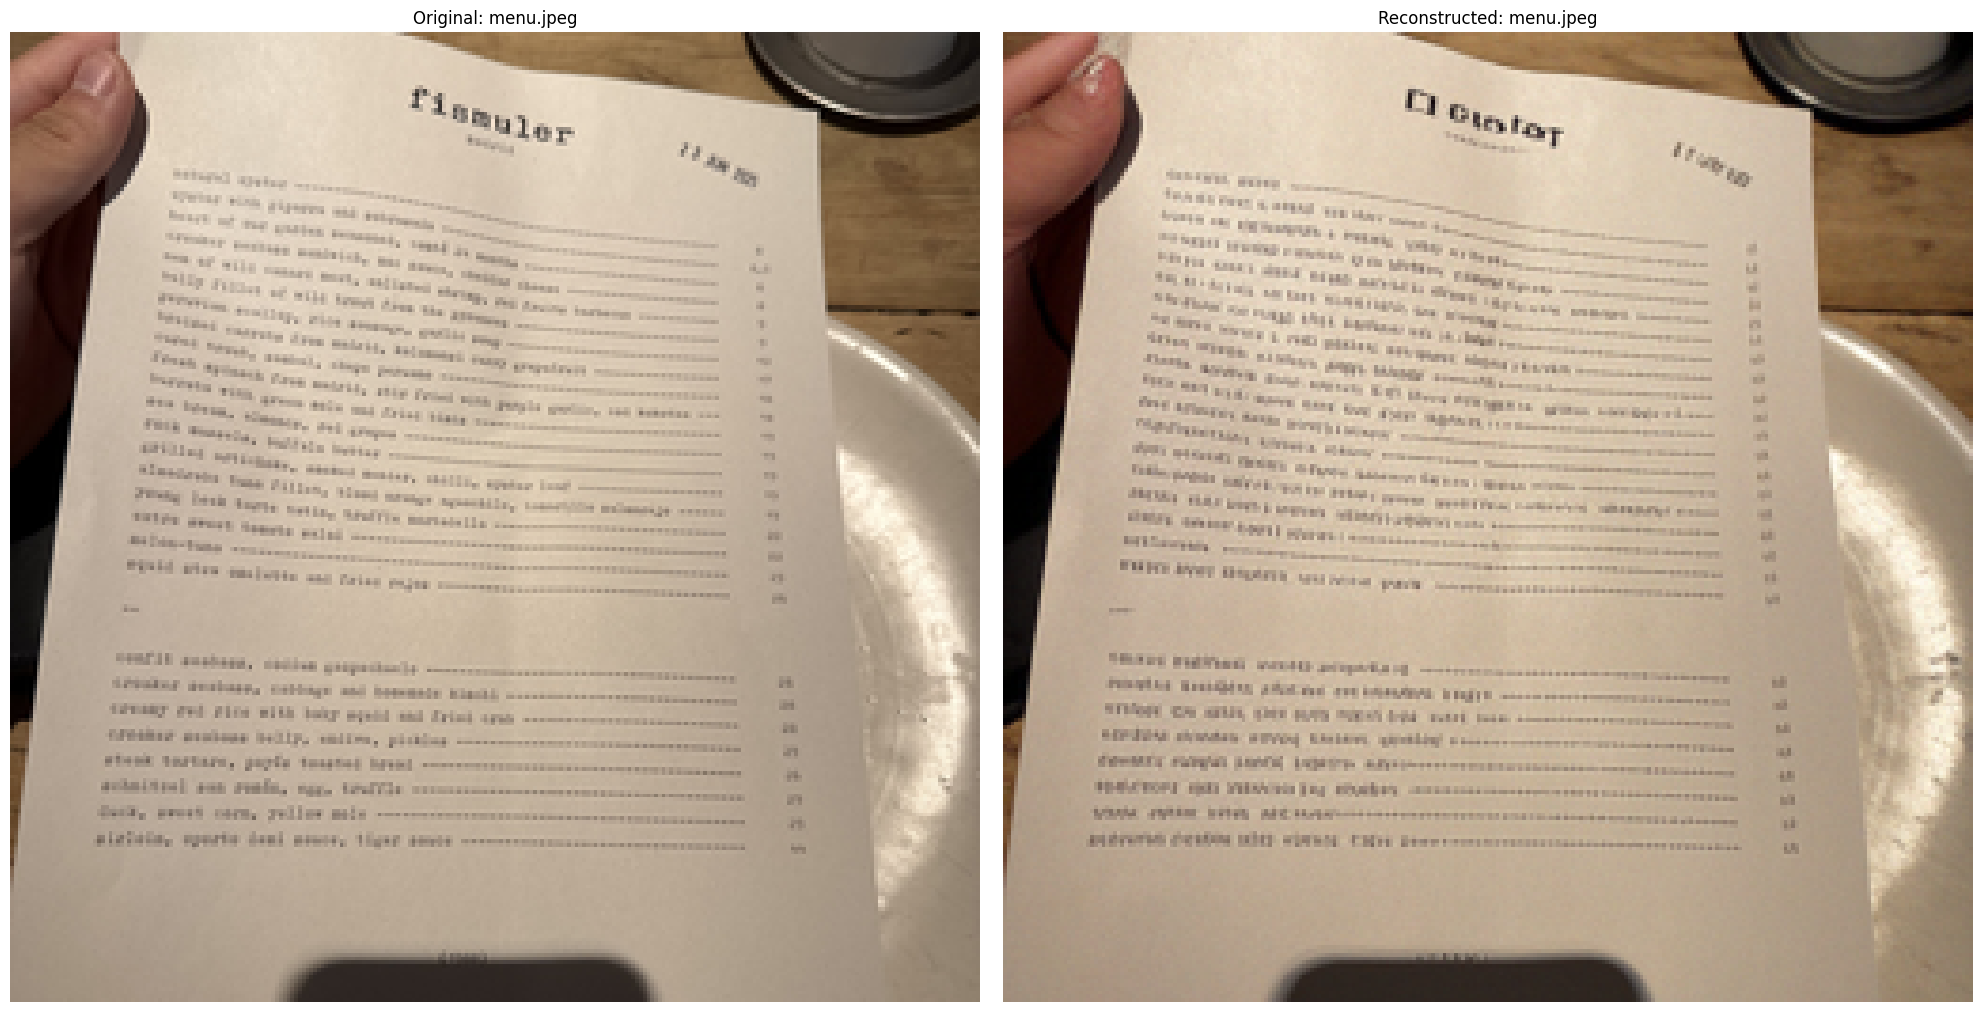


Processing image 7: physics1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: physics1_256.png


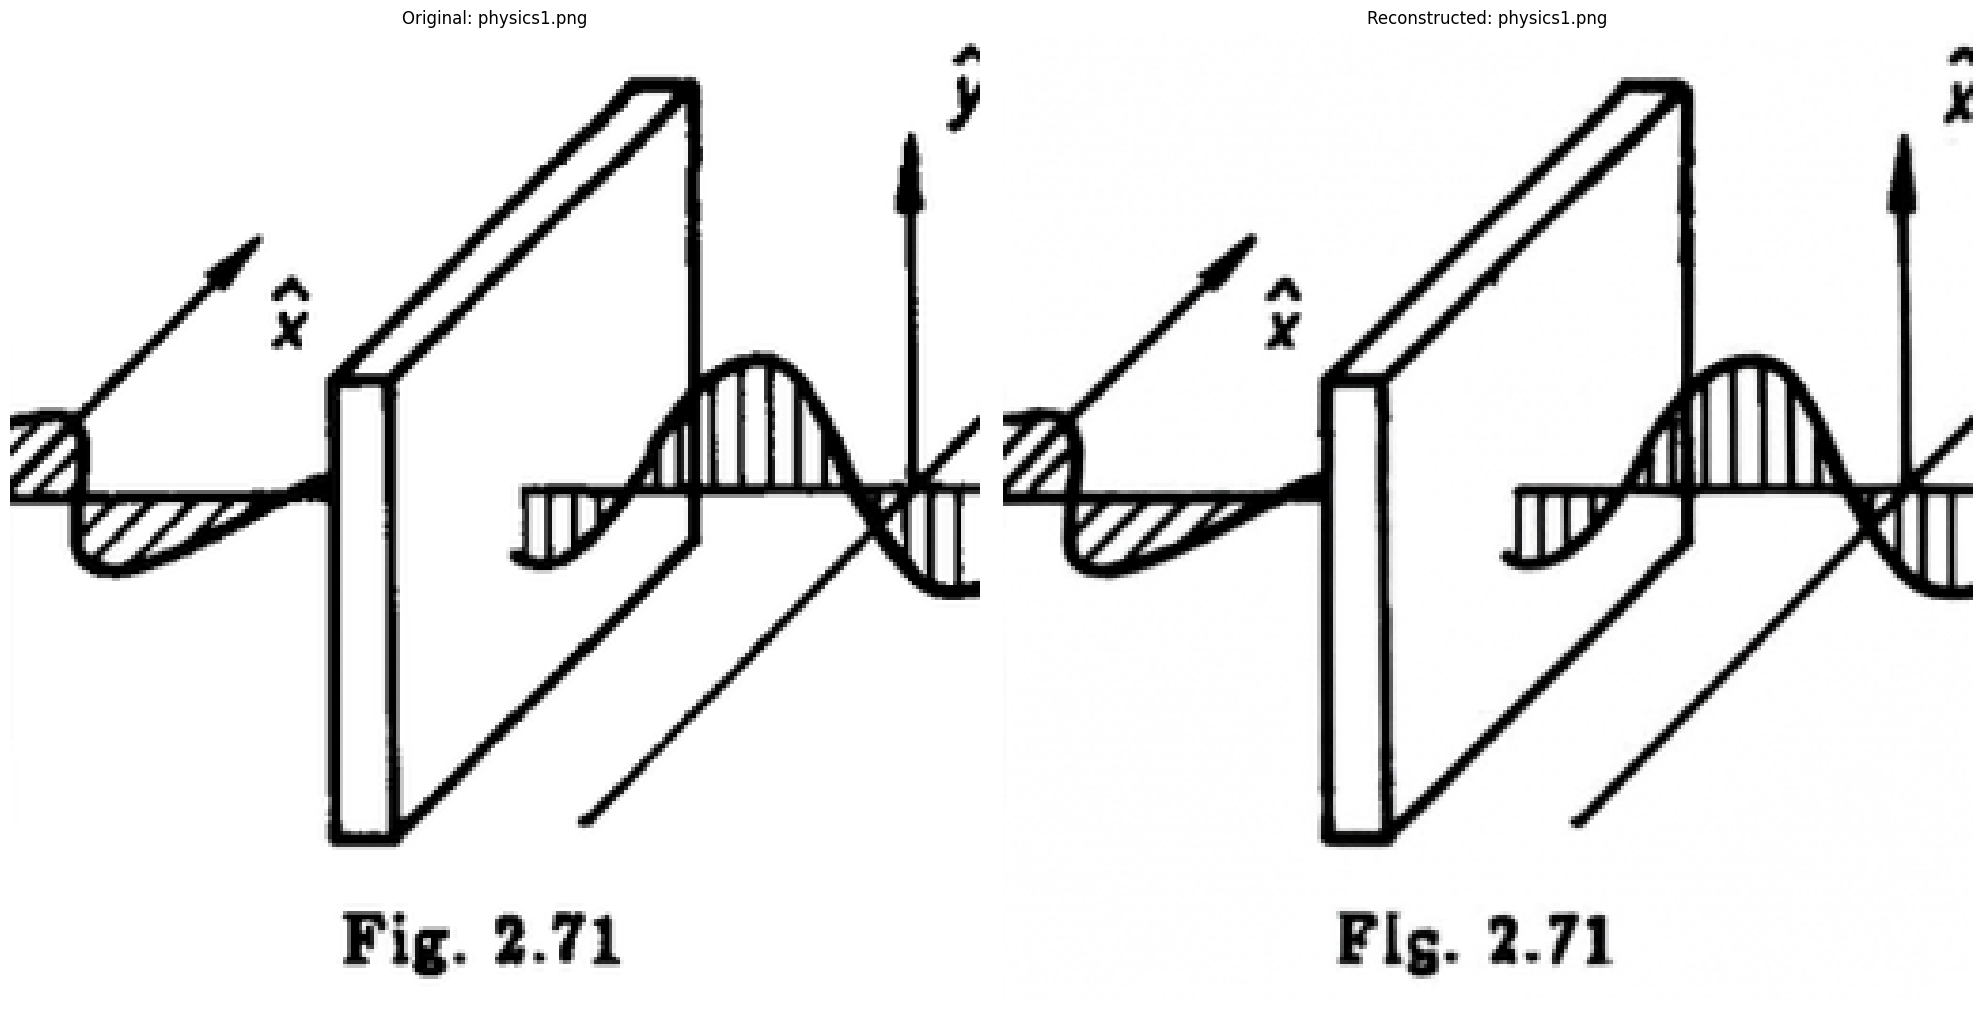


Processing image 8: physics2.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: physics2_256.png


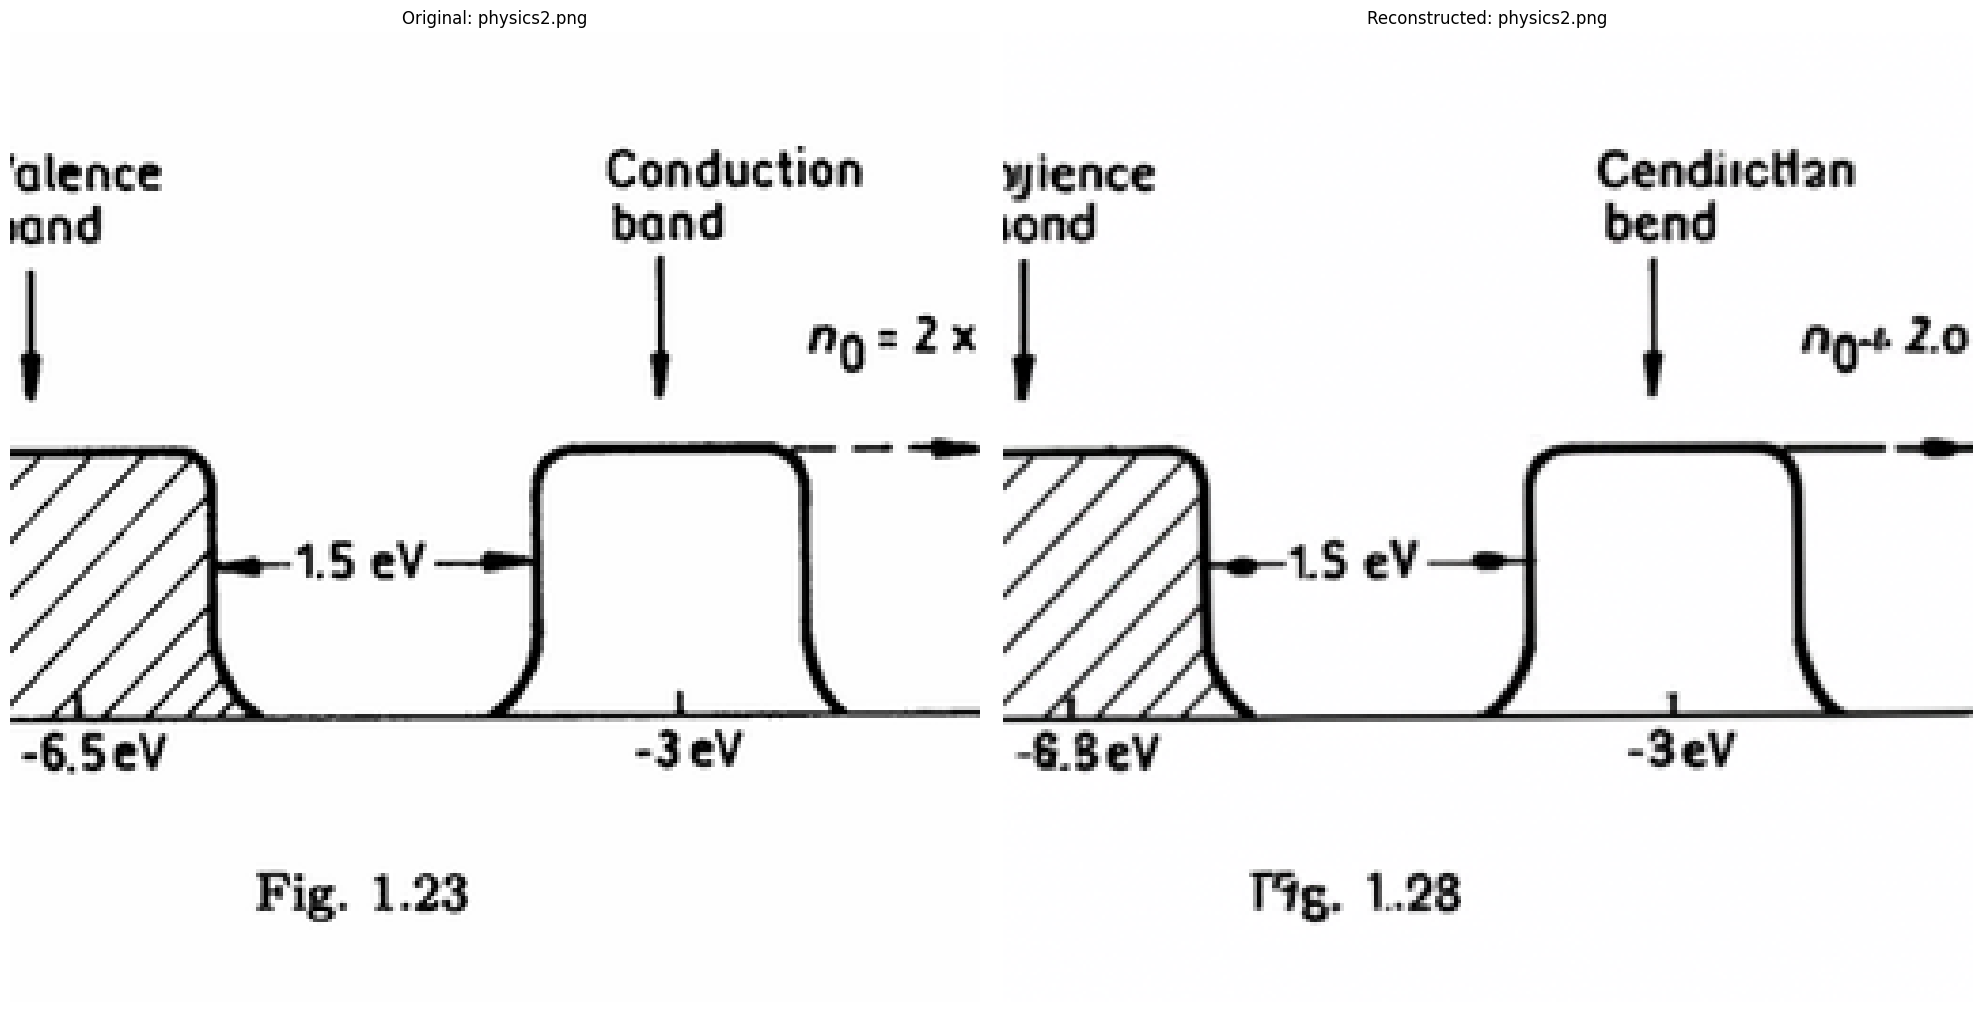

In [20]:
for idx, image_path in enumerate(image_paths):
    name = Path(image_path).name
    print(f"\nProcessing image {idx+1}: {name}")
    
    # Preprocess image
    image_tensor = preprocess_image(image_path, size=256, device='cuda')
    image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension
    
    print(f"Input image shape: {image_tensor.shape}")
    print(f"Image tensor device: {image_tensor.device}")
    
    # FlowMo reconstruction using model.reconstruct()
    with torch.no_grad():
        try:
            # Use model.reconstruct() directly - this handles everything internally
            recon = model.reconstruct(image_tensor)
            print(f"Reconstructed tensor shape: {recon.shape}")
            
            # Get number of tokens from model config
            num_tokens = model.code_length
            print(f"Number of tokens: {num_tokens}")
            print(f"Original image pixels: {image_tensor.shape[-2] * image_tensor.shape[-1]}")
            compression_ratio = (image_tensor.shape[-2] * image_tensor.shape[-1]) / num_tokens
            print(f"Compression ratio: {compression_ratio:.2f}x")
            
        except Exception as e:
            print(f"Error processing {name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Convert back to PIL images
    original_pil = tensor_to_pil(image_tensor)
    recon_pil = tensor_to_pil(recon)
    
    # Save reconstructed image with number of tokens
    name_without_ext = Path(name).stem
    output_filename = f"{name_without_ext}_{num_tokens}.png"
    recon_pil.save(os.path.join(RECONSTRUCTION_PATH, output_filename))
    print(f"Saved: {output_filename}")
    
    # Display comparison
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Original image
    axes[0].imshow(original_pil)
    axes[0].set_title(f"Original: {name}")
    axes[0].axis('off')
    
    # Reconstructed image
    axes[1].imshow(recon_pil)
    axes[1].set_title(f"Reconstructed: {name}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()